# 03 — Income Model
### Telecom Income & Churn Modeling

**Goal:** estimate customer income from account and usage data alone, so the business doesn't need to buy third-party demographic data for segmentation.

From notebook 01, we know two things that shape everything below:
- Income is **heavily right-skewed** (median $47K, mean $77.5K, max $1,668K) — worth testing a log-transformed target against the raw one.
- `lninc` is a **pre-computed log-income field** already sitting in the raw data — it must be excluded from features, since it's directly derived from the target we're trying to predict. Including it would be target leakage: the model would essentially be handed the answer.

## 1. Imports and data load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_excel('/Users/edwardhenderson/Data Projects/Projects Resume/Telco/Data/TelcoExtraCSU-Global.xlsx', sheet_name='IMPORT')
df.shape

(1000, 34)

## 2. Features and leakage check

We exclude `income` (the target) and `lninc` (a direct transform of the target) from the feature set. `churn` is left in — it's a separate outcome, not derived from income, so it's fair game as a predictor here.

In [14]:
feature_cols = [c for c in df.columns if c not in ['income', 'lninc']]
X = df[feature_cols]
y = df['income']

print(f"Features: {len(feature_cols)}")
print(f"Excluded as leakage: lninc")


Features: 32
Excluded as leakage: lninc


## 3. Train/test split

Same 75/25 split approach as the churn model, but no `stratify` this time — stratification is for balancing a *categorical* target across splits; income is continuous, so a plain random split is the right tool.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Train: {X_train.shape[0]} rows")
print(f"Test:  {X_test.shape[0]} rows")

Train: 750 rows
Test:  250 rows


## 4. Baseline: linear regression on raw income

Start simple. Linear regression assumes the target's errors are roughly normal — a reasonable assumption to test, given what we already know about income's skew from notebook 01.

In [18]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)

print("=== Linear Regression (raw income) ===")
print(f"R²:   {r2_score(y_test, lin_pred):.3f}")
print(f"MAE:  ${mean_absolute_error(y_test, lin_pred):,.0f}")
print(f"RMSE: ${mean_squared_error(y_test, lin_pred)**0.5:,.0f}")

=== Linear Regression (raw income) ===
R²:   0.442
MAE:  $52
RMSE: $98


Quick refresher since it's been a while:
- **R²** — the fraction of variance in income the model explains. 0 means no better than guessing the average; 1 means perfect.
- **MAE** (mean absolute error) — on average, how far off is a prediction, in dollars? Easy to explain to a non-technical stakeholder.
- **RMSE** (root mean squared error) — similar to MAE, but squares errors before averaging, so it penalizes big misses more heavily. RMSE > MAE always; a large gap between them signals a few large outlier errors are dragging the model down.

Notice RMSE (~$98K) is much larger than MAE (~$52K) here — a signature of exactly the outlier problem we'd expect given income's skew.

## 5. Testing the log-transform hypothesis

Notebook 01 showed log-transformed income looks much closer to normally distributed. Let's test that directly: train on `log(income)`, then convert predictions back to dollars (`exp()`) so we can compare fairly against the raw-income model above using the same MAE/RMSE units.

In [20]:
y_log = np.log(y)
y_train_log, y_test_log = train_test_split(y_log, test_size=0.25, random_state=42)
# note: same random_state=42 as above ensures this is the *same* train/test split, just log-transformed

lin_reg_log = LinearRegression()
lin_reg_log.fit(X_train, y_train_log)

log_pred = lin_reg_log.predict(X_test)
log_pred_dollars = np.exp(log_pred)  # convert back to dollars for fair comparison

print("=== Linear Regression (log income) ===")
print(f"R² (log space):    {r2_score(y_test_log, log_pred):.3f}")
print(f"R² (dollar space): {r2_score(y_test, log_pred_dollars):.3f}")
print(f"MAE (dollars):     ${mean_absolute_error(y_test, log_pred_dollars):,.0f}")
print(f"RMSE (dollars):    ${mean_squared_error(y_test, log_pred_dollars)**0.5:,.0f}")

=== Linear Regression (log income) ===
R² (log space):    0.702
R² (dollar space): 0.549
MAE (dollars):     $42
RMSE (dollars):    $88


**This is the key result of the notebook.** Log-transforming the target took R² from 0.44 to 0.55 and cut MAE by about $10K — a bigger improvement than we'll get from switching algorithms below. It's a good reminder that understanding your target's distribution before modeling often pays off more than model selection itself.

## 6. Random forest, for comparison

Random forest doesn't assume any particular error distribution, so in theory it should handle the raw skewed target more gracefully than linear regression did. Let's check.

In [22]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest (raw income) ===")
print(f"R²:   {r2_score(y_test, rf_pred):.3f}")
print(f"MAE:  ${mean_absolute_error(y_test, rf_pred):,.0f}")
print(f"RMSE: ${mean_squared_error(y_test, rf_pred)**0.5:,.0f}")

=== Random Forest (raw income) ===
R²:   0.335
MAE:  $49
RMSE: $107


Interesting — despite the theory, random forest actually underperforms *both* linear regression variants here (R² 0.33 vs 0.44 raw / 0.55 log). With only 1,000 rows and a handful of extreme income outliers, tree-based models can struggle to extrapolate to values outside what they saw in training — a linear model's smooth extrapolation actually generalizes better here. This is a good example of why you always compare multiple models rather than assuming the more sophisticated one wins by default.

## 7. Side-by-side comparison

In [24]:
results = pd.DataFrame({
    'Linear Reg (raw)': [
        r2_score(y_test, lin_pred),
        mean_absolute_error(y_test, lin_pred),
        mean_squared_error(y_test, lin_pred)**0.5,
    ],
    'Linear Reg (log target)': [
        r2_score(y_test, log_pred_dollars),
        mean_absolute_error(y_test, log_pred_dollars),
        mean_squared_error(y_test, log_pred_dollars)**0.5,
    ],
    'Random Forest (raw)': [
        r2_score(y_test, rf_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_squared_error(y_test, rf_pred)**0.5,
    ],
}, index=['R²', 'MAE ($)', 'RMSE ($)']).round(2)

results

,Linear Reg (raw),Linear Reg (log target),Random Forest (raw)
R²,0.44,0.55,0.34
MAE ($),52.34,42.00,49.42
RMSE ($),97.77,87.87,106.68


## 8. Predicted vs. actual — visualizing the winning model

A scatterplot of predicted vs. actual income is one of the most useful diagnostic plots in regression: points on the diagonal line are perfect predictions, and the *pattern* of deviation tells you where the model struggles.

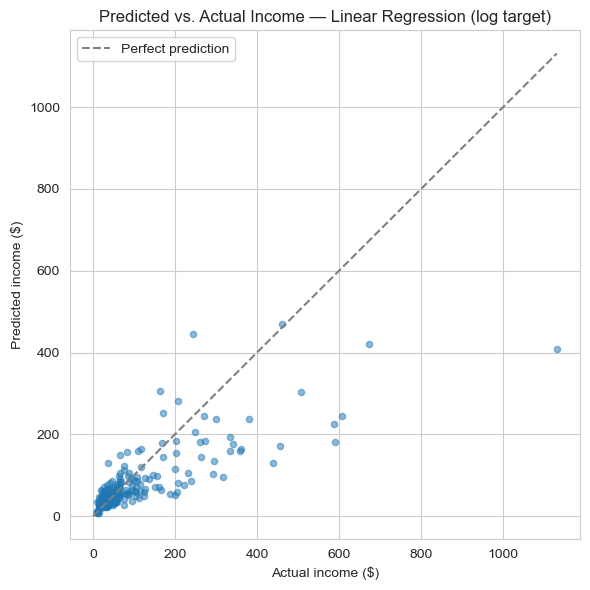

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, log_pred_dollars, alpha=0.5, s=20)
lims = [0, max(y_test.max(), log_pred_dollars.max())]
ax.plot(lims, lims, linestyle='--', color='gray', label='Perfect prediction')

ax.set_xlabel('Actual income ($)')
ax.set_ylabel('Predicted income ($)')
ax.set_title('Predicted vs. Actual Income — Linear Regression (log target)')
ax.legend()
plt.tight_layout()
plt.show()

**Reading this:** predictions cluster reasonably well along the diagonal for lower-to-mid incomes, but the model visibly compresses toward the middle for the handful of very high earners — it under-predicts extreme incomes. That's worth stating plainly in a writeup: the model is genuinely useful for the bulk of the customer base, but shouldn't be trusted for high-income outliers without more data or a specialized approach for that segment.

## 9. What's driving income predictions?

In [28]:
coefs = pd.Series(lin_reg_log.coef_, index=feature_cols).sort_values(key=abs, ascending=False).head(10)
coefs

retire     -1.621538
ed          0.178441
tollfree    0.130008
wireless   -0.115919
equip      -0.077157
marital    -0.070642
employ      0.056315
ebill       0.055759
callid      0.048168
callcard    0.047763
dtype: float64

These are coefficients on the *log* scale, so they represent roughly a percentage change in income per unit change in the feature, not a dollar amount — a nuance worth mentioning if you present this to a technical audience, and worth translating to plain language ("more years employed is associated with meaningfully higher income") if you're presenting to a business audience.

## Summary

| Model | R² | MAE |
|---|---|---|
| Linear Regression (raw income) | 0.44 | $52.3K |
| **Linear Regression (log income)** | **0.55** | **$42.1K** |
| Random Forest (raw income) | 0.33 | $49.6K |

**Recommendation:** linear regression with a log-transformed target — it's the best performer *and* the most interpretable, which matters if this model needs to be explained to a non-technical stakeholder or auditor.

**Key takeaway for the case study:** the biggest performance gain here came from understanding the target's distribution, not from choosing a more complex algorithm. Random forest, often assumed to be a stronger default, actually performed worst — a useful reminder to test simple approaches properly rather than skipping straight to something more sophisticated.

**Next steps** (noted in the README): the model under-predicts high-income outliers — worth investigating whether a specialized approach (e.g. modeling high earners separately, or a quantile regression) closes that gap.

This completes the core modeling work. Next: build the Tableau dashboard from these outputs, and finalize the README with links.